1. Data Loading and Preparation:
• Consider the last three digits of your student ID number and store them in the variable
studID.
• Load the contents of the file output.csv into a pandas DataFrame.
• Sort the DataFrame by the column "market_cap".
• Extract the company corresponding to the position indicated by studID.
• From the selected company, note its sector and industry details.

In [59]:
import pandas as pd

# --------------------------
# 1. Data Loading and Preparation
# --------------------------

# Store the last three digits of your student ID in the variable studID
studID = 360

# Load the contents of the file output.csv into a pandas DataFrame
df = pd.read_csv('output.csv')

# Get general info about the DataFrame
df.info()  # Summary of the DataFrame structure

# Sort the DataFrame by the column "market_cap" in ascending order
df_sorted = df.sort_values(by="market_cap", ascending=True)

# Extract the company corresponding to the position indicated by studID
# Use modulo to ensure the index is within the bounds of the DataFrame
company_index = studID % len(df_sorted)
selected_company = df_sorted.iloc[company_index]

# Extract the sector and industry details of the selected company
selected_sector = selected_company['sector']
selected_industry = selected_company['industry']

# Print the results
print(f"Selected Company: {selected_company['company_name']}")
print(f"Sector: {selected_sector}")
print(f"Industry: {selected_industry}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 38 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   symbol                1000 non-null   object 
 1   company_name          1000 non-null   object 
 2   sector                998 non-null    object 
 3   industry              998 non-null    object 
 4   market_cap            1000 non-null   int64  
 5   enterprise_value      1000 non-null   uint64 
 6   current_price         1000 non-null   float64
 7   previous_close        1000 non-null   float64
 8   fifty_two_week_high   1000 non-null   float64
 9   fifty_two_week_low    1000 non-null   float64
 10  fifty_day_average     1000 non-null   float64
 11  two_hundred_day_avg   1000 non-null   float64
 12  beta                  1000 non-null   float64
 13  pe_trailing           1000 non-null   float64
 14  pe_forward            1000 non-null   float64
 15  price_to_sales        

2. Stock Data Retrieval:
• Using the symbol from the selected company, retrieve the daily stock data for the last 3
months via the yfinance library.
• This data will be used to plot the daily trend of the company.

In [49]:
import pandas as pd
import yfinance as yf
from datetime import datetime, timedelta

# --------------------------
# 1. Data Loading and Preparation
# --------------------------

# Store the last three digits of your student ID in the variable studID
studID = 360

# Load the contents of the file output.csv into a pandas DataFrame
df = pd.read_csv('output.csv')

# Sort the DataFrame by the column "market_cap" in ascending order
df_sorted = df.sort_values(by="market_cap", ascending=True)

# Extract the company corresponding to the position indicated by studID
# Use modulo to ensure the index is within the bounds of the DataFrame
company_index = studID % len(df_sorted)
selected_company = df_sorted.iloc[company_index]

# Extract the symbol of the selected company
selected_symbol = selected_company['symbol']

# Print the selected company details
print(f"Selected Company: {selected_company['company_name']}")
print(f"Symbol: {selected_symbol}")
print(f"Sector: {selected_company['sector']}")
print(f"Industry: {selected_company['industry']}")

# --------------------------
# 2. Retrieve Daily Stock Data for the Last 3 Months
# --------------------------

# Define the date range for the last 3 months
end_date = datetime.now()
start_date = end_date - timedelta(days=90)

# Retrieve the daily stock data using yfinance
stock_data = yf.download(selected_symbol, start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))

# Print the first few rows of the stock data
print(stock_data.head())

# Save the stock data for later use in plotting
stock_data.to_csv(f"{selected_symbol}_last_3_months.csv")

[*********************100%***********************]  1 of 1 completed

Selected Company: CF Industries Holdings, Inc.
Symbol: CF
Sector: Basic Materials
Industry: Agricultural Inputs
Price           Close       High        Low       Open   Volume
Ticker             CF         CF         CF         CF       CF
Date                                                           
2025-01-28  89.696045  90.143280  88.582917  88.781694  1827100
2025-01-29  91.952110  92.041562  89.328315  90.361933  2119500
2025-01-30  91.634079  92.538497  90.938379  91.465124  1464600
2025-01-31  91.644020  92.131010  90.898624  91.475065  1595500
2025-02-03  91.902420  92.041560  88.821449  90.679966  1613700


• Plot 1: A line chart showing the daily trend (closing price) over the last 3 months of the
selected company’s stock data, with the selected company’s data highlighted in Color#1.

[*********************100%***********************]  1 of 1 completed

Selected Company: CF Industries Holdings, Inc.
Symbol: CF
Sector: Basic Materials
Industry: Agricultural Inputs
Price           Close       High        Low       Open   Volume
Ticker             CF         CF         CF         CF       CF
Date                                                           
2025-01-28  89.696045  90.143280  88.582917  88.781694  1827100
2025-01-29  91.952110  92.041562  89.328315  90.361933  2119500
2025-01-30  91.634079  92.538497  90.938379  91.465124  1464600
2025-01-31  91.644020  92.131010  90.898624  91.475065  1595500
2025-02-03  91.902420  92.041560  88.821449  90.679966  1613700


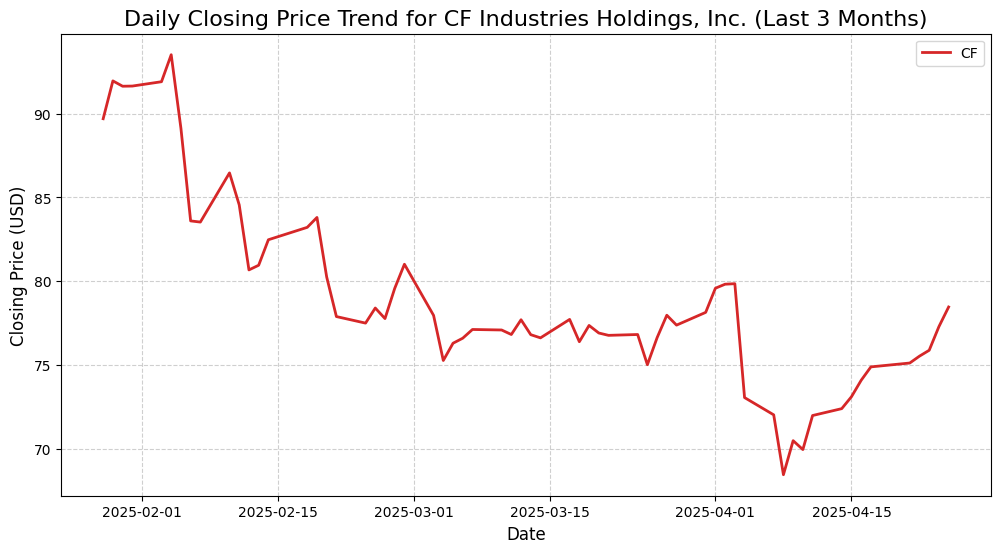

In [60]:
import pandas as pd
import yfinance as yf
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

# --------------------------
# 1. Data Loading and Preparation
# --------------------------

# Store the last three digits of your student ID in the variable studID
studID = 360

# Load the contents of the file output.csv into a pandas DataFrame
df = pd.read_csv('output.csv')

# Sort the DataFrame by the column "market_cap" in ascending order
df_sorted = df.sort_values(by="market_cap", ascending=True)

# Extract the company corresponding to the position indicated by studID
# Use modulo to ensure the index is within the bounds of the DataFrame
company_index = studID % len(df_sorted)
selected_company = df_sorted.iloc[company_index]

# Extract the symbol of the selected company
selected_symbol = selected_company['symbol']

# Print the selected company details
print(f"Selected Company: {selected_company['company_name']}")
print(f"Symbol: {selected_symbol}")
print(f"Sector: {selected_company['sector']}")
print(f"Industry: {selected_company['industry']}")

# --------------------------
# 2. Retrieve Daily Stock Data for the Last 3 Months
# --------------------------

# Define the date range for the last 3 months
end_date = datetime.now()
start_date = end_date - timedelta(days=90)

# Retrieve the daily stock data using yfinance
stock_data = yf.download(selected_symbol, start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))

# Print the first few rows of the stock data
print(stock_data.head())

# --------------------------
# 3. Plot the Daily Trend (Closing Price)
# --------------------------

# Define colors
color_selected = "#d62728"  # Color#1 for the selected company (red)
color_others = "##2ca02"    # Color#2 for others (blue)

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(stock_data.index, stock_data['Close'], label=selected_symbol, color=color_selected, linewidth=2)

# Add labels and title
plt.title(f"Daily Closing Price Trend for {selected_company['company_name']} (Last 3 Months)", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Closing Price (USD)", fontsize=12)

# Add a legend
plt.legend()

# Show the plot
plt.grid(visible=True, linestyle='--', alpha=0.6)
plt.show()

 Plot 2: A bar chart comparing the market capitalization of the top 10 companies in the same
sector as the selected company. A dashed line indicates the average market cap for that
sector. All companies are shown in Color#2, while the selected company is highlighted in
Color#1.

Selected Company: CF Industries Holdings, Inc.
Symbol: CF
Sector: Basic Materials
Industry: Agricultural Inputs


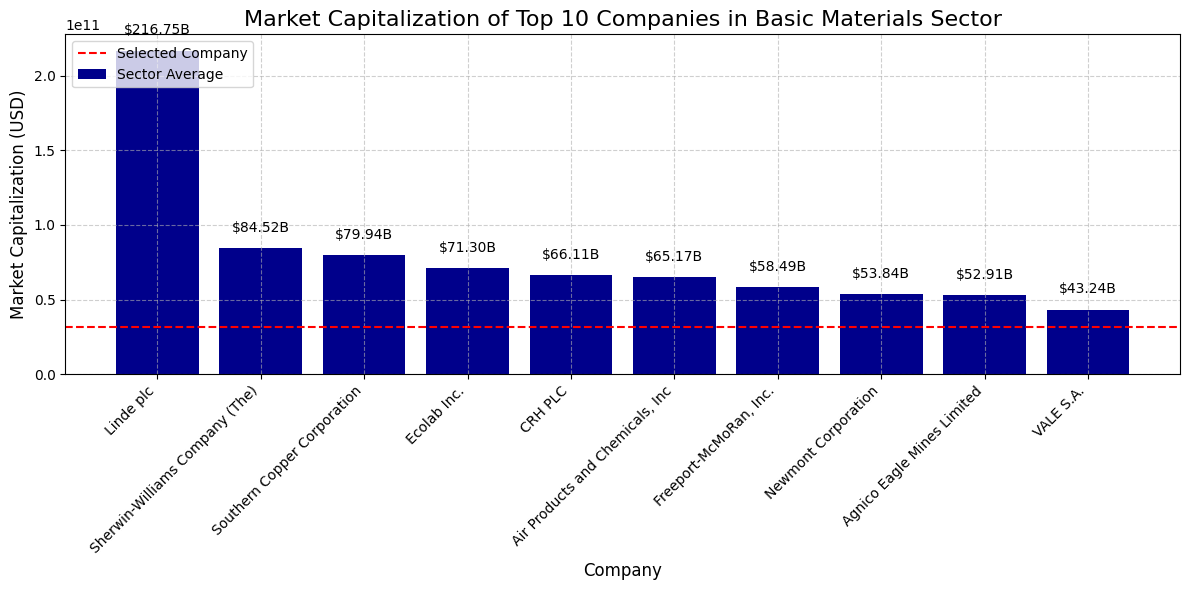

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------
# 1. Data Loading and Preparation
# --------------------------

# Store the last three digits of your student ID in the variable studID
studID = 360

# Load the contents of the file output.csv into a pandas DataFrame
df = pd.read_csv('output.csv')

# Sort the DataFrame by the column "market_cap" in ascending order
df_sorted = df.sort_values(by="market_cap", ascending=True)

# Extract the company corresponding to the position indicated by studID
# Use modulo to ensure the index is within the bounds of the DataFrame
company_index = studID % len(df_sorted)
selected_company = df_sorted.iloc[company_index]

# Extract the symbol of the selected company
selected_symbol = selected_company['symbol']

# Print the selected company details
print(f"Selected Company: {selected_company['company_name']}")
print(f"Symbol: {selected_symbol}")
print(f"Sector: {selected_company['sector']}")
print(f"Industry: {selected_company['industry']}")

# --------------------------
# 2. Bar Chart: Market Capitalization of Top 10 Companies in the Same Sector
# --------------------------

# Filter the DataFrame to include only companies in the same sector as the selected company
same_sector_companies = df_sorted[df_sorted['sector'] == selected_company['sector']]

# Sort by market capitalization in descending order and select the top 10 companies
top_10_companies = same_sector_companies.nlargest(10, 'market_cap')

# Calculate the average market capitalization for the sector
average_market_cap = same_sector_companies['market_cap'].mean()

# Define colors for the bar chart
colors = [
    "#A9A9A9" if row['symbol'] == selected_symbol else "#00008B"  # Dark blue for selected company, light gray for others
    for _, row in top_10_companies.iterrows()
]

# Create the bar chart
plt.figure(figsize=(12, 6))
bars = plt.bar(
    top_10_companies['company_name'], 
    top_10_companies['market_cap'], 
    color=colors
)

# Add a dashed line for the average market capitalization
plt.axhline(y=average_market_cap, color='red', linestyle='--', linewidth=1.5, label='Sector Average')

# Annotate each bar with the market capitalization value
for bar, value in zip(bars, top_10_companies['market_cap']):
    plt.text(
        bar.get_x() + bar.get_width() / 2, 
        bar.get_height() + 0.05 * max(top_10_companies['market_cap']), 
        f"${value / 1e9:.2f}B", 
        ha='center', 
        fontsize=10, 
        color='black'
    )

# Highlight the selected company with a bold label
for bar, company in zip(bars, top_10_companies['company_name']):
    if company == selected_company['company_name']:
        bar.set_edgecolor('gold')
        bar.set_linewidth(2)

# Add labels and title
plt.title(f"Market Capitalization of Top 10 Companies in {selected_company['sector']} Sector", fontsize=16)
plt.xlabel("Company", fontsize=12)
plt.ylabel("Market Capitalization (USD)", fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add a legend
plt.legend(["Selected Company", "Sector Average"], loc="upper left")

# Show the plot
plt.grid(visible=True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

 Plot 3: A similar bar chart comparing the market cap of the top 10 companies in the same
industry as the selected company, with a dashed line indicating the average market cap for the
industry. Again, all companies are shown in Color#2 except the selected company, which is
highlighted in Color#1

Selected Company: CF Industries Holdings, Inc.
Symbol: CF
Sector: Basic Materials
Industry: Agricultural Inputs


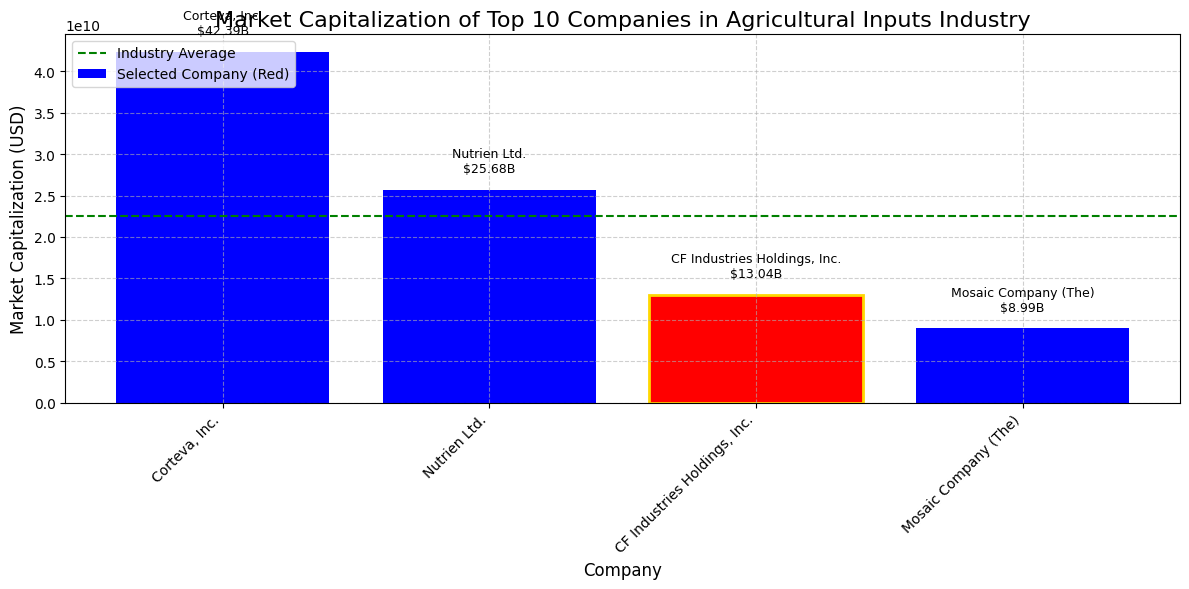

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------
# 1. Data Loading and Preparation
# --------------------------

# Store the last three digits of your student ID in the variable studID
studID = 360

# Load the contents of the file output.csv into a pandas DataFrame
df = pd.read_csv('output.csv')

# Sort the DataFrame by the column "market_cap" in ascending order
df_sorted = df.sort_values(by="market_cap", ascending=True)

# Extract the company corresponding to the position indicated by studID
# Use modulo to ensure the index is within the bounds of the DataFrame
company_index = studID % len(df_sorted)
selected_company = df_sorted.iloc[company_index]

# Extract the symbol of the selected company
selected_symbol = selected_company['symbol']

# Print the selected company details
print(f"Selected Company: {selected_company['company_name']}")
print(f"Symbol: {selected_symbol}")
print(f"Sector: {selected_company['sector']}")
print(f"Industry: {selected_company['industry']}")

# --------------------------
# 2. Bar Chart: Market Capitalization of Top 10 Companies in the Same Industry
# --------------------------

# Filter the DataFrame to include only companies in the same industry as the selected company
same_industry_companies = df_sorted[df_sorted['industry'] == selected_company['industry']]

# Sort by market capitalization in descending order
same_industry_companies = same_industry_companies.sort_values(by="market_cap", ascending=False)

# Check if there are fewer than 10 companies in the industry
if len(same_industry_companies) < 10:
    print(f"Warning: Only {len(same_industry_companies)} companies found in the same industry.")
    top_10_companies = same_industry_companies
else:
    top_10_companies = same_industry_companies.head(10)

# Calculate the average market capitalization for the industry
average_market_cap = same_industry_companies['market_cap'].mean()

# Define colors for the bar chart
colors = [
    "#FF0000" if row['symbol'] == selected_symbol else "#0000FF"  # Red for selected company, blue for others
    for _, row in top_10_companies.iterrows()
]

# Create the bar chart
plt.figure(figsize=(12, 6))
bars = plt.bar(
    top_10_companies['company_name'], 
    top_10_companies['market_cap'], 
    color=colors
)

# Add a dashed line for the average market capitalization
plt.axhline(y=average_market_cap, color='green', linestyle='--', linewidth=1.5, label='Industry Average')

# Annotate each bar with the company name and market capitalization value
for bar, row in zip(bars, top_10_companies.itertuples()):
    plt.text(
        bar.get_x() + bar.get_width() / 2, 
        bar.get_height() + 0.05 * max(top_10_companies['market_cap']), 
        f"{row.company_name}\n${row.market_cap / 1e9:.2f}B", 
        ha='center', 
        fontsize=9, 
        color='black'
    )

# Highlight the selected company with a bold label
for bar, company in zip(bars, top_10_companies['company_name']):
    if company == selected_company['company_name']:
        bar.set_edgecolor('gold')
        bar.set_linewidth(2)

# Add labels and title
plt.title(f"Market Capitalization of Top 10 Companies in {selected_company['industry']} Industry", fontsize=16)
plt.xlabel("Company", fontsize=12)
plt.ylabel("Market Capitalization (USD)", fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add a legend
plt.legend(["Industry Average", "Selected Company (Red)", "Other Companies (Blue)"], loc="upper left")

# Show the plot
plt.grid(visible=True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

 Plot 4: A scatter plot displaying the relationship between "total_revenue" and "net_income"
for companies in the same sector. All companies are plotted in Color#2, while the selected
company is distinguished by a larger Color#1 marker.

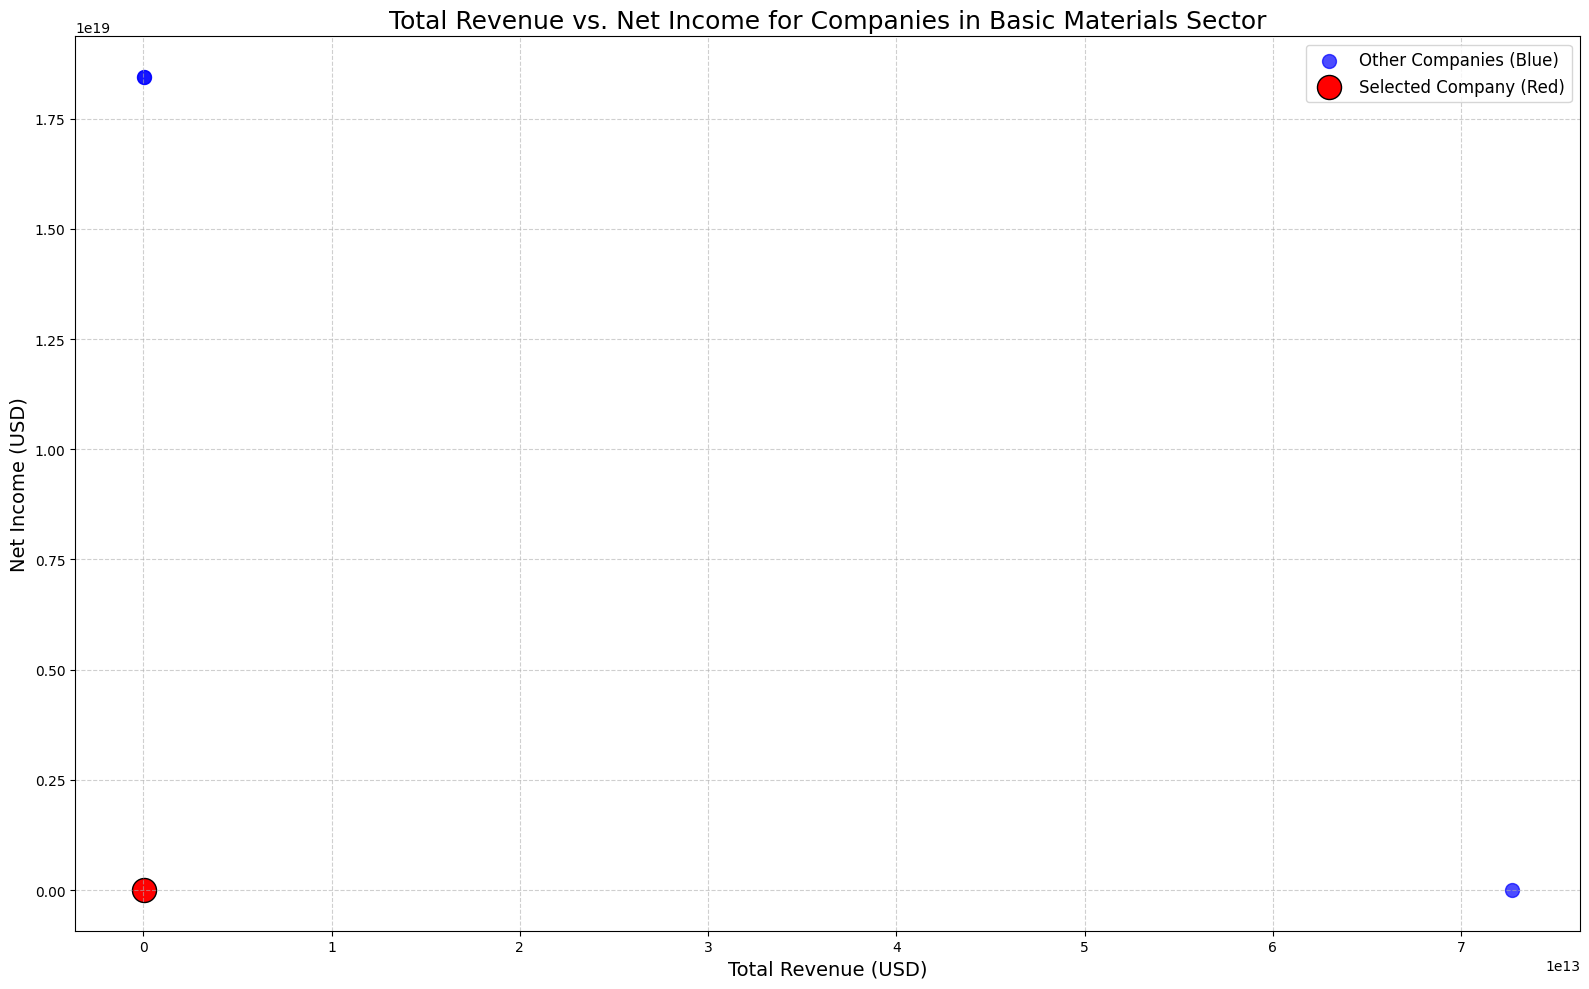

In [53]:
import matplotlib.pyplot as plt

# --------------------------
# 2. Scatter Plot: Total Revenue vs. Net Income
# --------------------------

# Filter the DataFrame to include only companies in the same sector as the selected company
same_sector_companies = df_sorted[df_sorted['sector'] == selected_sector]

# Extract the total_revenue and net_income columns for the scatter plot
x = same_sector_companies['total_revenue']
y = same_sector_companies['net_income']

# Extract the selected company's revenue and net income
selected_revenue = selected_company['total_revenue']
selected_net_income = selected_company['net_income']

# Create the scatter plot with larger dimensions
plt.figure(figsize=(16, 10))  # Larger dimensions for better readability
plt.scatter(x, y, color="#0000FF", label="Other Companies (Blue)", alpha=0.7, s=100)  # Larger circles for other companies
plt.scatter(selected_revenue, selected_net_income, color="#FF0000", label="Selected Company (Red)", s=300, edgecolor='black')  # Larger circle for selected company

# Add labels and title
plt.title(f"Total Revenue vs. Net Income for Companies in {selected_sector} Sector", fontsize=18)
plt.xlabel("Total Revenue (USD)", fontsize=14)
plt.ylabel("Net Income (USD)", fontsize=14)

# Add a legend
plt.legend(fontsize=12)

# Show the plot
plt.grid(visible=True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


4. Final Layout:
• Combine all four plots into a single figure with subplots to provide a comprehensive and
coherent analysis of the selected company in comparison to its peers

[*********************100%***********************]  1 of 1 completed


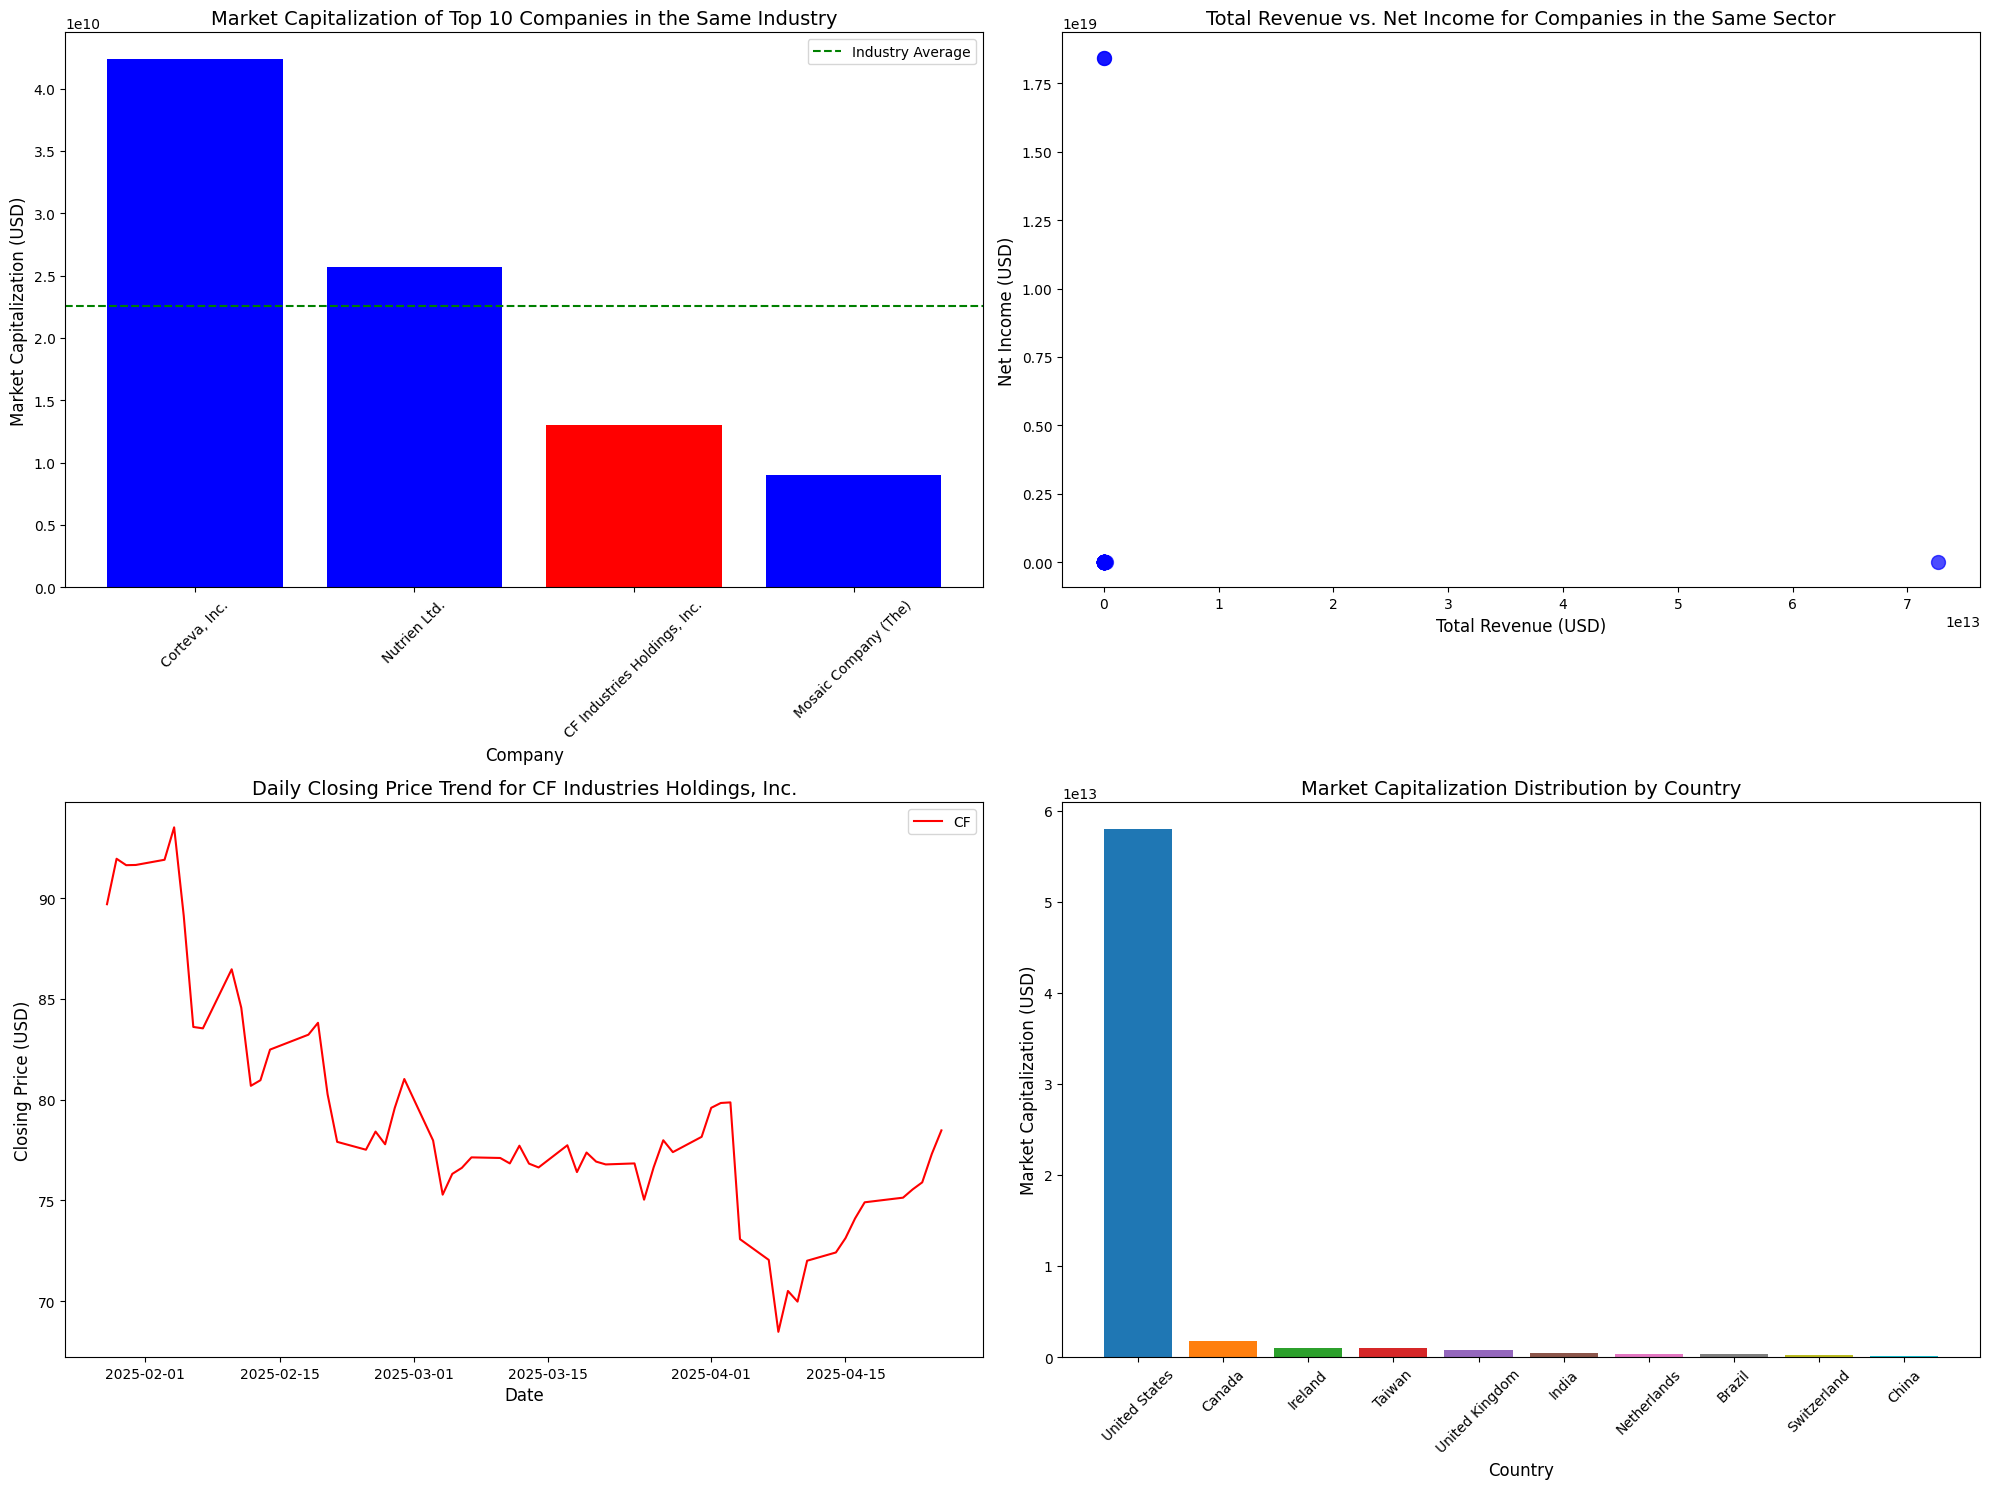

In [58]:
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# --------------------------
# Data Loading and Preparation
# --------------------------

# Store the last three digits of your student ID in the variable studID
studID = 360

# Load the contents of the file output.csv into a pandas DataFrame
df = pd.read_csv('output.csv')

# Sort the DataFrame by the column "market_cap" in ascending order
df_sorted = df.sort_values(by="market_cap", ascending=True)

# Extract the company corresponding to the position indicated by studID
company_index = studID % len(df_sorted)
selected_company = df_sorted.iloc[company_index]

# Extract the sector and industry details of the selected company
selected_sector = selected_company['sector']
selected_industry = selected_company['industry']
selected_symbol = selected_company['symbol']

# --------------------------
# Subplot 1: Bar Chart - Market Capitalization of Top 10 Companies in the Same Industry
# --------------------------

# Filter the DataFrame to include only companies in the same industry as the selected company
same_industry_companies = df_sorted[df_sorted['industry'] == selected_industry]
top_10_companies = same_industry_companies.nlargest(10, 'market_cap')

# Calculate the average market capitalization for the industry
average_market_cap = same_industry_companies['market_cap'].mean()

# Define colors for the bar chart
colors = [
    "#FF0000" if row['symbol'] == selected_symbol else "#0000FF"  # Red for selected company, blue for others
    for _, row in top_10_companies.iterrows()
]

# --------------------------
# Subplot 2: Scatter Plot - Total Revenue vs. Net Income for Companies in the Same Sector
# --------------------------

# Filter the DataFrame to include only companies in the same sector as the selected company
same_sector_companies = df_sorted[df_sorted['sector'] == selected_sector]

# Extract the total_revenue and net_income columns for the scatter plot
x_scatter = same_sector_companies['total_revenue']
y_scatter = same_sector_companies['net_income']

# --------------------------
# Subplot 3: Line Chart - Daily Closing Price Trend of the Selected Company
# --------------------------

# Define the date range for the last 3 months
end_date = pd.Timestamp.now()
start_date = end_date - pd.DateOffset(months=3)

# Retrieve the daily stock data using yfinance
stock_data = yf.download(selected_symbol, start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'))

# --------------------------
# Subplot 4: Bar Chart - Market Capitalization Distribution by Country
# --------------------------

# Group the DataFrame by country and calculate the total market capitalization
country_market_cap = df_sorted.groupby('country')['market_cap'].sum().reset_index()

# Sort by market capitalization in descending order and limit to top 10 countries
top_countries = country_market_cap.nlargest(10, 'market_cap')

# --------------------------
# Combine All Plots into a Single Figure
# --------------------------

fig, axes = plt.subplots(2, 2, figsize=(20, 15))  # Create a 2x2 grid of subplots

# Subplot 1: Bar Chart
axes[0, 0].bar(top_10_companies['company_name'], top_10_companies['market_cap'], color=colors)
axes[0, 0].axhline(y=average_market_cap, color='green', linestyle='--', linewidth=1.5, label='Industry Average')
axes[0, 0].set_title("Market Capitalization of Top 10 Companies in the Same Industry", fontsize=14)
axes[0, 0].set_xlabel("Company", fontsize=12)
axes[0, 0].set_ylabel("Market Capitalization (USD)", fontsize=12)
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].legend()

# Subplot 2: Scatter Plot
axes[0, 1].scatter(x_scatter, y_scatter, color="#0000FF", alpha=0.7, s=100)
axes[0, 1].set_title("Total Revenue vs. Net Income for Companies in the Same Sector", fontsize=14)
axes[0, 1].set_xlabel("Total Revenue (USD)", fontsize=12)
axes[0, 1].set_ylabel("Net Income (USD)", fontsize=12)

# Subplot 3: Line Chart
axes[1, 0].plot(stock_data.index, stock_data['Close'], color="#FF0000", label=selected_symbol)
axes[1, 0].set_title(f"Daily Closing Price Trend for {selected_company['company_name']}", fontsize=14)
axes[1, 0].set_xlabel("Date", fontsize=12)
axes[1, 0].set_ylabel("Closing Price (USD)", fontsize=12)
axes[1, 0].legend()

# Subplot 4: Bar Chart for Market Capitalization by Country
axes[1, 1].bar(top_countries['country'], top_countries['market_cap'], color=cm.tab10.colors)
axes[1, 1].set_title("Market Capitalization Distribution by Country", fontsize=14)
axes[1, 1].set_xlabel("Country", fontsize=12)
axes[1, 1].set_ylabel("Market Capitalization (USD)", fontsize=12)
axes[1, 1].tick_params(axis='x', rotation=45)

# Adjust layout
plt.tight_layout()
plt.show()